<a href="https://colab.research.google.com/github/7amokarim/Protein-Family-Classification/blob/main/Protein_Family_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install biopython pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 45.7 MB/s eta 0:00:00


In [2]:
from google.colab import files

uploaded = files.upload()

Saving uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (3).gz to uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (3).gz
Saving uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (2).gz to uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (2).gz
Saving uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (1).gz to uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (1).gz
Saving uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta.gz to uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta.gz


In [3]:
print(uploaded.keys())

dict_keys(['uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (3).gz', 'uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (2).gz', 'uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (1).gz', 'uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta.gz'])


In [30]:
import gzip
import random
from Bio import SeqIO

file_names = [
'uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta.gz',
'uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (1).gz',
'uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (2).gz',
'uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (3).gz'
]

data=[]

labels=[
"kinase",
"protease",
"transporter",
"receptor"
]

for file,label in zip(file_names,labels):

    with gzip.open(file,'rt') as f:

        sequences=list(
            SeqIO.parse(
                f,
                "fasta"
            )
        )

        random.shuffle(
            sequences
        )

        sequences=sequences[:250]

        for seq in sequences:

            data.append(
                [
                    str(seq.seq),
                    label
                ]
            )

print("Total samples:",
      len(data))

print(data[:2])

Total samples: 1000
[['MAEEEETAALTEKVIRTQRVFINLLDSYSSGNIGKFLSNCVVGASLEEITEEEEEEDENKSAMLEASSTKVKEGTFQIVGTLSKPDSPRPDFAVETYSAISREDLLMRLLECDVIIYNITESSQQMEEAIWAVSALSEEVSHFEKRKLFILLSTVMTWARSKALDPEDSEVPFTEEDYRRRKSHPNFLDHINAEKMVLKFGKKARKFAAYVVAAGLQYGAEGGMLHTFFKMAWLGEIPALPVFGDGTNVIPTIHVLDLAGVIQNVIDHVPKPHYLVAVDESVHTLEDIVKCISKNTGPGKIQKIPRENAYLTKDLTQDCLDHLLVNLRMEALFVKENFNIRWAAQTGFVENINTILKEYKQSRGLMPIKICILGPPAVGKSSIAKELANYYKLHHIQLKDVISEAIAKLEAIVAPNDVGEGEEEVEEEEEEENVEDAQELLDGIKESMEQNAGQLDDQYIIRFMKEKLKSMPCRNQGYILDGFPKTYDQAKDLFNQEDEEEEDDVRGRMFPFDKLIIPEFVCALDASDEFLKERVINLPESIVAGTHYSQDRFLRALSNYRDINIDDETVFNYFDELEIHPIHIDVGKLEDAQNRLAIKQLIKEIGEPRNYGLTDEEKAEEERKAAEERLAREAAEEAEREHQEAVEMAEKIARWEEWNKRLEEVKREERELLEAQSIPLRNYLMTYVMPTLIQGLNECCNVRPEDPVDFLAEYLFKNNPEAQ', 'kinase'], ['MTHGEELGSDVHQDSIVLTYLEGLLMHQAAGGSGTAVDKKSAGHNEEDQNFNISGSAFPTCQSNGPVLNTHTYQGSGMLHLKKARLLQSSEDWNAAKRKRLSDSIMNLNVKKEALLAGMVDSVPKGKQDSTLLASLLQSFSSRLQTVALSQQIRQSLKEQGYALSHDSLKVEKDLRCYGVASSHLKTLLKKSKVKDQKPDTNLPDVTKNLIRDRFAESPHHVGQSGTKVMSEPLSCAA

In [31]:
import pandas as pd

df=pd.DataFrame(
    data,
    columns=[
        "sequence",
        "label"
    ]
)

print(df.head())

print(df.shape)

                                            sequence   label
0  MAEEEETAALTEKVIRTQRVFINLLDSYSSGNIGKFLSNCVVGASL...  kinase
1  MTHGEELGSDVHQDSIVLTYLEGLLMHQAAGGSGTAVDKKSAGHNE...  kinase
2  MLLRSKPALPPPLMLLLLGPLGPLSPGALPRPAQAQDVVDLDFFTQ...  kinase
3  MAGPATQSPMKLMALQLLLWHSALWTVQEATPLGPASSLPQSFLLK...  kinase
4  MEEGGSTGSAGSDSSTSGSGGAQQRELERMAEVLVTGEQLRLRLHE...  kinase
(1000, 2)


In [41]:
from collections import Counter

def get_kmers(sequence,k=4):

    return [sequence[i:i+k]
            for i in range(len(sequence)-k+1)]

all_kmers=[]

for seq in df["sequence"]:

    all_kmers.extend(get_kmers(seq))

top_kmers=[x[0]
            for x in Counter(all_kmers).most_common(1000)]

print("Number of kmers:",len(top_kmers))

Number of kmers: 1000


In [42]:
def vectorize(sequence):

    kmers=get_kmers(sequence)

    counts=Counter(kmers)

    return [counts[k] for k in top_kmers]

X=df["sequence"].apply(vectorize)

X=pd.DataFrame(X.tolist())

y=df["label"]

In [43]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score

model=RandomForestClassifier(
    n_estimators=100
)

model.fit(X_train,y_train)

pred=model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred))

print(classification_report(
    y_test,
    pred
))

Accuracy: 0.35
              precision    recall  f1-score   support

      kinase       0.30      0.36      0.33        44
    protease       0.33      0.44      0.38        52
    receptor       0.29      0.18      0.23        49
 transporter       0.47      0.40      0.43        55

    accuracy                           0.35       200
   macro avg       0.35      0.35      0.34       200
weighted avg       0.35      0.35      0.35       200



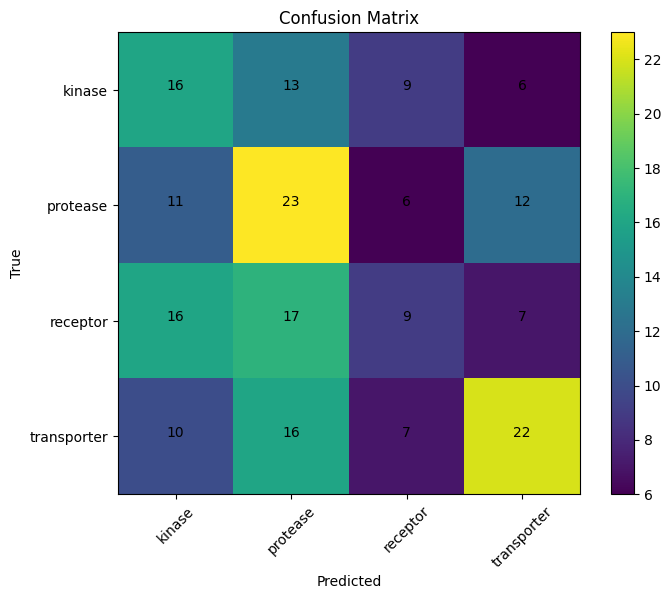

In [45]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test,pred)

labels=[
'kinase',
'protease',
'receptor',
'transporter'
]

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
np.arange(len(labels)),
labels,
rotation=45
)

plt.yticks(
np.arange(len(labels)),
labels
)

plt.xlabel(
"Predicted"
)

plt.ylabel(
"True"
)

plt.title(
"Confusion Matrix"
)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(
            j,
            i,
            cm[i,j],
            ha='center'
        )

plt.show()

In [46]:
import pandas as pd

comparison = pd.DataFrame({

"Model":[
"Random Forest",
"Random Forest"
],

"k":[
3,
4
],

"Accuracy":[
0.375,
0.35
]

})

print(comparison)

           Model  k  Accuracy
0  Random Forest  3     0.375
1  Random Forest  4     0.350


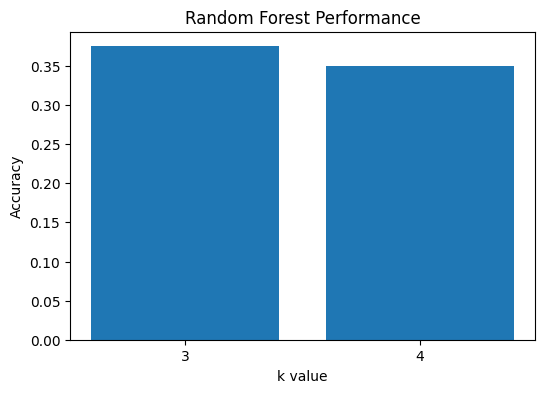

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
comparison["k"].astype(str),
comparison["Accuracy"]
)

plt.xlabel("k value")

plt.ylabel("Accuracy")

plt.title("Random Forest Performance")

plt.show()

# ==========================
# Student C - 1D CNN
# ==========================

In [48]:
!pip install tensorflow

In [49]:
import tensorflow as tf
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [50]:
amino_acids = "ACDEFGHIKLMNPQRSTVWY"

char_to_int = {
    c:i+1
    for i,c in enumerate(amino_acids)
}

def encode_seq(seq):

    return [

        char_to_int.get(
            x,
            0
        )

        for x in seq
    ]

X_encoded = [
    encode_seq(seq)
    for seq in df["sequence"]
]

X = pad_sequences(
    X_encoded,
    maxlen=500,
    padding='post'
)

encoder=LabelEncoder()

y=encoder.fit_transform(
    df["label"]
)

print(X.shape)
print(y.shape)

(1000, 500)
(1000,)


In [51]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(800, 500)
(200, 500)


In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()

model.add(
    Embedding(
        input_dim=21,
        output_dim=32,
        input_length=500
    )
)

model.add(
    Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu'
    )
)

model.add(
    MaxPooling1D(
        pool_size=2
    )
)

model.add(
    Flatten()
)

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dropout(
        0.5
    )
)

model.add(
    Dense(
        4,
        activation='softmax'
    )
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [53]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.2547 - loss: 1.4016 - val_accuracy: 0.2750 - val_loss: 1.3886
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3578 - loss: 1.3572 - val_accuracy: 0.2750 - val_loss: 1.3882
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4578 - loss: 1.2710 - val_accuracy: 0.2188 - val_loss: 1.3817
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5094 - loss: 1.1426 - val_accuracy: 0.3125 - val_loss: 1.3848
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6656 - loss: 0.9036 - val_accuracy: 0.3625 - val_loss: 1.3620
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8047 - loss: 0.6281 - val_accuracy: 0.3750 - val_loss: 1.4890
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8500 - loss: 0.4792 - val_accuracy: 0.3625 - val_loss: 1.6909
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9000 - loss: 0.3418 - val_accuracy: 0.3500 - val_

In [54]:
loss,acc = model.evaluate(
    X_test,
    y_test
)

print(
"Test Accuracy:",
acc
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - accuracy: 0.3400 - loss: 1.9129
Test Accuracy: 0.3400000035762787


In [55]:
import numpy as np
from sklearn.metrics import classification_report

pred = model.predict(X_test)

pred = np.argmax(
    pred,
    axis=1
)

print(
classification_report(
    y_test,
    pred
))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step
              precision    recall  f1-score   support

           0       0.21      0.18      0.19        44
           1       0.41      0.17      0.24        52
           2       0.29      0.31      0.30        49
           3       0.41      0.65      0.51        55

    accuracy                           0.34       200
   macro avg       0.33      0.33      0.31       200
weighted avg       0.34      0.34      0.32       200



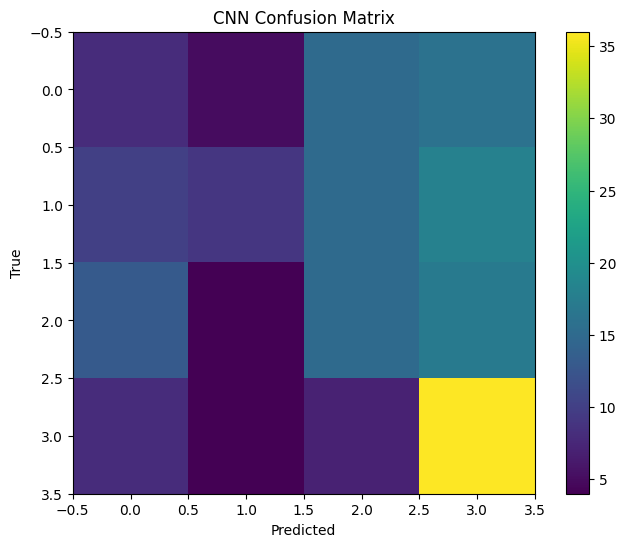

In [56]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm=confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.colorbar()

plt.title(
"CNN Confusion Matrix"
)

plt.xlabel(
"Predicted"
)

plt.ylabel(
"True"
)

plt.show()